# **Kaggle Environment Setup:**

In [1]:
# Installing the missing libraries
# This command has worked so far somewhat reliably, you can also try the other ones if it doesn't, and if it's still not working contact the TAs
!pip3 install chromadb langchain_community langchain_google_genai langextract ollama pymupdf "scikit-learn<1.4" umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of umap-learn to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of google-api-core[grpc] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 89.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.6/124.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 91.1 MB/s et

In [2]:
# Install the missing libraries in the kaggle environment manually like this if needed
#!pip3 install chromadb==1.1.0 langchain_community==0.3.29 langchain_google_genai==2.1.12 langextract==1.0.9 ollama==0.5.4 pymupdf==1.26.4

In [3]:
# In case of the library test not working you can uncomment this line and run the full library installation with the versions
# that worked when testing the lab
#!pip3 install python-dotenv==1.1.1 google-genai==1.21.1 langextract==1.0.9 gensim==4.3.3 tensorflow==2.18.0 tensorflow-hub==0.16.1 keras==3.8.0 ollama==0.5.4 langchain==0.3.27 langchain_community==0.3.29 langchain_core==0.3.76 langchain-google-genai==2.1.12 beautifulsoup4==4.13.4 chromadb==1.1.0 gradio==5.31.0  scikit-learn==1.2.2 pandas==2.2.3 numpy==1.26.4 matplotlib==3.7.2 plotly==5.24.1 seaborn==0.12.2 nltk==3.9.1 umap-learn==0.5.7 pymupdf==1.26.4

In [4]:
# test code for environment setup
# import library
from bs4 import BeautifulSoup
import chromadb
import dotenv
import gradio
from google import genai
import jupyter
import langchain
from langchain_community import utils
from langchain_core import prompts
from langchain_google_genai import chat_models
import langextract
import matplotlib
import nltk
import numpy
import pandas
import plotly
import pymupdf
import seaborn
import sklearn
import umap

%matplotlib inline

2025-11-28 05:52:06.776044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764309127.171573      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764309127.283506      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 2](#toc1_)    
  - [Before Starting](#toc1_1_)    
  - [Introduction](#toc1_2_)    
  - [**1. Data Preparation**](#toc1_3_)    
  - [**1.1 Load data**](#toc1_4_)    
    - [**1.2 Save data**](#toc1_4_1_)    
  - [**2. Large Language Models (LLMs)**](#toc1_5_)    
    - [Open-Source vs. Proprietary LLMs](#toc1_5_1_)    
    - [Why Use Code (API) for Data Mining?](#toc1_5_2_)    
    - [The Gemini API](#toc1_5_3_)    
    - [Interacting with the Gemini API](#toc1_5_4_)    
    - [**2.1 Text Prompting**](#toc1_5_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_5_1_1_)    
    - [**2.2 Structured Output**](#toc1_5_6_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_5_6_1_1_)    
    - [**2.3 Information Extraction and Grounding:**](#toc1_5_7_)    
      - [**`langextract`: A Library for Grounded Extraction**](#toc1_5_7_1_)    
        - [**2.3.1 Using PDF Documents:**](#toc1_5_7_1_1_)    
        - [**>>> Bonus Exercise 3 (Take home):**](#toc1_5_7_1_2_)    
    - [**2.4 Generating LLM Embeddings:**](#toc1_5_8_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_5_8_1_1_)    
    - [**2.5 Retrieval-Augmented Generation (RAG)**](#toc1_5_9_)    
        - [**Actual answer in the URL:**](#toc1_5_9_1_1_)    
        - [**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc1_5_9_1_2_)    
        - [**>>> Bonus Exercise 5 (Take home):**](#toc1_5_9_1_3_)    
    - [**2.6 Few-Shot Prompting Classification:**](#toc1_5_10_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_5_10_1_1_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_5_10_1_2_)    
    - [**2.7 Extra LLM Related Materials:**](#toc1_5_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 2](#toc0_)
In this lab's phase 2 session we will focus on exploring some basic LLMs' applications with data.


## <a id='toc1_1_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_2_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/pics/pic0.png?raw=True)

---
## <a id='toc1_3_'></a>[**1. Data Preparation**](#toc0_)

---
## <a id='toc1_4_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [5]:
import pandas as pd

### training data
anger_train = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [6]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [7]:
### testing data
anger_test = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("/kaggle/input/lab2-initial-data/data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [8]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [9]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
### <a id='toc1_4_1_'></a>[**1.2 Save data**](#toc0_)

In [10]:
import os
os.makedirs("./data", exist_ok=True)
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [11]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
## <a id='toc1_5_'></a>[**2. Large Language Models (LLMs)**](#toc0_)

Before we start we strongly suggest that you watch the following video explanations so you can understand the concepts that we are gonna discuss about LLMs: 

1. [How Large Language Models Work](https://www.youtube.com/watch?v=5sLYAQS9sWQ)
2. [Large Language Models explained briefly](https://www.youtube.com/watch?v=LPZh9BOjkQs)
3. [What is Prompt Tuning?](https://www.youtube.com/watch?v=yu27PWzJI_Y)
4. [Why Large Language Models Hallucinate](https://www.youtube.com/watch?v=cfqtFvWOfg0)
5. [What are LLM Embeddings?](https://www.youtube.com/watch?v=UShw_1NbpCw&t=182s)
6. [What is Retrieval-Augmented Generation (RAG)?](https://www.youtube.com/watch?v=T-D1OfcDW1M)
7. [RAG vs Fine-Tuning vs Prompt Engineering: Optimizing AI Models](https://www.youtube.com/watch?v=zYGDpG-pTho)
8. [Discover Few-Shot Prompting | Google AI Essentials](https://www.youtube.com/watch?v=9qdgEBVkWR4)
9. [What is Zero-Shot Learning?](https://www.youtube.com/watch?v=pVpr4GYLzAo)
10. [Zero-shot, One-shot and Few-shot Prompting Explained | Prompt Engineering 101](https://www.youtube.com/watch?v=sW5xoicq5TY)

`These videos can help you get a better grasp on the core concepts of LLMs if you were not familiar before.`

**So now let's start with the main content of Lab 2 Phase 2.**

Large Language Models (LLMs) are AI systems trained on vast amounts of text to understand and generate human language for tasks like summarization and translation.

### <a id='toc1_5_1_'></a>[Open-Source vs. Proprietary LLMs](#toc0_)
*   **Open-Source Models** (e.g., Llama, Gemma) are customizable and cost-effective but require technical skill to manage and may be less powerful.
*   **Proprietary Models** (e.g., Gemini, ChatGPT) offer top performance and ease of use but are more costly and less flexible.

For students interested in running models locally, the optional notebook `DM2025-Lab2-Optional-Ollama.ipynb` explores using Ollama ([Ollama GitHub Link](https://github.com/ollama/ollama)). It needs a capable GPU to run models (**at least 4GB VRAM**).

You can explore the variety of models available through Ollama here:

![pic10.png](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/pics/pic10.png?raw=True)

### <a id='toc1_5_2_'></a>[Why Use Code (API) for Data Mining?](#toc0_)

For data analysis, accessing LLMs programmatically is superior to using web chatbots because it allows for:
*   **Automation:** Easily process entire datasets with loops.
*   **Structured Output:** Receive data in usable formats like **JSON**, ready for analysis in tools like pandas.
*   **Reproducibility:** Ensure consistent results by setting fixed parameters.
*   **Privacy:** Maintain data security, especially when running models locally.

For the main exercises in this lab, we will use **the Gemini API**. This approach offers several advantages over running local open-source models, such as access to state-of-the-art model performance without needing specialized hardware. While the API has usage limits (rate limits and token quotas), it provides a generous **free tier** that is more than sufficient for our exercises.

![pic13.png](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/pics/pic13.png?raw=True)

![pic14.png](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/pics/pic14.png?raw=True)

### <a id='toc1_5_3_'></a>[The Gemini API](#toc0_)

We will primarily use the **Gemini 2.5 Flash-Lite** (`gemini-2.5-flash-lite`) model. As shown in the rate limit table, this model is optimized for high-frequency tasks and offers a high request-per-day limit of 1,000, making it ideal for completing the lab exercises without interruption.

Students are encouraged to explore other models available through the API but should remain mindful of their respective usage limits. For instance:
*   **Gemini 2.5 Pro** is a more powerful model but has a lower daily request limit of 100.
*   The **Gemma 3** model available via the API offers an impressive 14,400 requests per day, providing another excellent alternative for experimentation.

Please be aware of your usage limits as you work through the exercises to ensure you do not get rate-limited.

[Gemini Documentation](https://ai.google.dev/gemini-api/docs)

[Gemini Rate Limits](https://ai.google.dev/gemini-api/docs/rate-limits)

[Description of Gemini Models](https://ai.google.dev/gemini-api/docs/models)

---

### <a id='toc1_5_4_'></a>[Interacting with the Gemini API](#toc0_)

The code cell below contains the primary function, `prompt_gemini`, that we will use throughout this lab to communicate with the Gemini API. It's designed to be a flexible wrapper that handles the details of sending a request and receiving a response.

Before you run the exercises, here are the key things you need to understand in this setup:

*   **API Key Configuration**: The script loads your API key from a `.env` file located in the `./config/` directory. **You must create this file and add your API key** like this: `GOOGLE_API_KEY='YOUR_API_KEY_HERE'`. This is a security best practice to keep your credentials out of the code.

*   **Global Settings**: At the top of the script, you can find and modify several important defaults:
    *   `MODEL_NAME`: We've set this to `"gemini-2.5-flash-lite"`, but you can easily switch to other models like `"gemini-2.5-pro"` to experiment.
    *   `SYSTEM_INSTRUCTION`: This sets the model's default behavior or persona (e.g., "You are a helpful assistant"). You can customize this for different tasks.
    *   `SAFETY_SETTINGS`: For our academic exercises, these are turned off to prevent interference. In real-world applications, you would configure these carefully.

*   **The `prompt_gemini` function**: This is the main tool you will use. Here are its most important parameters:
    *   `input_prompt`: The list of contents (text, images, etc.) you want to send to the model.
    *   `temperature`: Controls the randomness of the output. `0.0` makes the output deterministic and less creative, while a higher value (e.g., `0.7`) makes it more varied.
    *   `schema`: A powerful feature that allows you to specify a JSON format for the model's output. This is extremely useful for structured data extraction.
    *   `with_tokens_info`: If set to `True`, the function will also return the number of input and output tokens used, which is helpful for monitoring your usage against the free tier limits.

In the following exercises, you will call this function with different prompts and configurations to solve various tasks.

If needed, you can also check some tutorials on how a python function works: [Python Functions Tutorial](https://realpython.com/defining-your-own-python-function/)

In [12]:
import os
from google import genai
from google.genai import types
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()


# System instruction that can dictate how the model behaves in the output, can be customized as needed
SYSTEM_INSTRUCTION = (
        "You are a helpful assistant"
    )

# Max amount of tokens that the model can output, the Gemini 2.5 Models have this maximum amount
# For other models need to check their documentation 
MAX_OUTPUT_TOKENS = 65535
MODEL_NAME = "gemini-2.5-flash-lite" # Other models: "gemini-2.5-pro", "gemini-2.5-flash"; Check different max output tokens: "gemini-2.0-flash" , "gemini-2.0-flash-lite" 

# We disable the safety settings, as no moderation is needed in our tasks
SAFETY_SETTINGS = [
    types.SafetySetting(
        category="HARM_CATEGORY_HATE_SPEECH", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_HARASSMENT", threshold="OFF")
]

# We input the API Key to be able to use the Gemini models
api_key = user_secrets.get_secret("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key
client = genai.Client(api_key=api_key)

# We also set LangExtract to use the API key as well:
if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = api_key

def prompt_gemini(
        input_prompt: list,
        schema = None,
        temperature: float = 0.0,
        system_instruction: str = SYSTEM_INSTRUCTION,
        max_output_tokens: int = MAX_OUTPUT_TOKENS,
        client: genai.Client = client,
        model_name: str = MODEL_NAME,
        new_config: types.GenerateContentConfig = None,
        with_tools: bool = False,
        with_parts: bool = False,
        with_tokens_info: bool = False
    ):
        try:
            # If we need a JSON schema we set up the following
            if schema:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    response_mime_type="application/json",
                    response_schema=schema,
                    safety_settings=SAFETY_SETTINGS
                )
            # If there is no need we leave it unstructured
            else:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    safety_settings=SAFETY_SETTINGS
                )
            
            # We add a different custom configuration if we need it
            if new_config:
                generate_content_config = new_config
            
            # For some tasks we need a more specific way to add the contents when prompting the model
            # So we need custom parts for it sometimes from the "types" objects
            if with_parts:
                response = client.models.generate_content(
                    model=model_name,
                    contents=types.Content(parts=input_prompt),
                    config=generate_content_config,
                )
            # In the simplest form the contents can be expressed as a list [] of simple objects like str and Pillow images
            else:
                response = client.models.generate_content(
                    model=model_name,
                    contents=input_prompt,
                    config=generate_content_config,
                )

            if with_tools:
                # print(response)
                # Include raw response when function calling
                completion = response
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    return completion, log
                return completion
            else:
                completion = response.text
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    # Return the text response and logs (if selected)
                    return completion, log
                return completion
        except Exception as e:
             print(f"Error occurred when generating response, error: {e}")
             return None

---
### <a id='toc1_5_5_'></a>[**2.1 Text Prompting**](#toc0_)

In the same way as with ChatGPT we can use the Gemini models to ask about anything. Here we are going to ask a question requesting the response to be in markdown format, this is to make it have a better display afterwards.

For more information visit:
[Gemini's Text Generation Documentation](https://ai.google.dev/gemini-api/docs/text-generation)

In [13]:
input_prompt = ["What is Data Mining?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, with_tokens_info = True)
print(text_response)

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strat

We can also check the logs of the usage with our model that we defined in our previous function. We can observe the model we used, how many tokens where in the prompt in the input, and the output text response tokens of our model.

In [14]:
print(logs)

{'model': 'gemini-2.5-flash-lite', 'input_tokens': 12, 'output_tokens': 911}


**We can use the IPython library to make the response look better:**

In [15]:
from IPython.display import display, Markdown
display(Markdown(text_response))

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strategic planning.

**How it Works (The Process):**

Data mining is usually an iterative process that involves several stages:

1.  **Business Understanding:** Defining the problem or objective you want to achieve with data mining. What questions are you trying to answer? What business goals are you trying to meet?
2.  **Data Understanding:** Exploring and getting familiar with the data. This involves collecting, cleaning, and understanding the data's structure, quality, and meaning.
3.  **Data Preparation (Preprocessing):** This is often the most time-consuming stage. It involves:
    *   **Cleaning:** Handling missing values, noisy data, and inconsistencies.
    *   **Integration:** Combining data from multiple sources.
    *   **Transformation:** Normalizing or aggregating data to make it suitable for mining.
    *   **Reduction:** Reducing the size of the dataset while preserving important information.
4.  **Modeling:** Selecting and applying appropriate data mining techniques (algorithms) to discover patterns. This is where the "mining" happens.
5.  **Evaluation:** Assessing the quality and usefulness of the discovered patterns. Do they make sense? Are they statistically significant? Do they meet the business objectives?
6.  **Deployment:** Putting the discovered knowledge into practice. This could involve integrating it into business processes, creating reports, or building predictive models.

**Common Data Mining Techniques:**

Data mining employs a variety of techniques, often drawing from statistics, machine learning, and database systems. Some of the most common include:

*   **Classification:** Categorizing data into predefined classes (e.g., predicting whether a customer will churn or not).
*   **Clustering:** Grouping similar data points together without predefined classes (e.g., segmenting customers into different groups based on their purchasing behavior).
*   **Association Rule Mining:** Discovering relationships between items in a dataset (e.g., "customers who buy bread also tend to buy milk"). This is often used in market basket analysis.
*   **Regression:** Predicting a continuous numerical value (e.g., predicting the price of a house based on its features).
*   **Anomaly Detection (Outlier Detection):** Identifying data points that deviate significantly from the norm (e.g., detecting fraudulent transactions).
*   **Sequential Pattern Mining:** Discovering patterns that occur in a sequence over time (e.g., identifying common user navigation paths on a website).

**Why is Data Mining Important?**

Data mining is crucial for businesses and organizations because it enables them to:

*   **Make Better Decisions:** By understanding customer behavior, market trends, and operational efficiencies, organizations can make more informed and strategic decisions.
*   **Improve Customer Relationships:** Identifying customer preferences and predicting their needs allows for personalized marketing, better customer service, and increased loyalty.
*   **Detect Fraud and Risk:** Anomaly detection can help identify fraudulent activities, security breaches, and potential risks.
*   **Optimize Operations:** Understanding patterns in operational data can lead to improved efficiency, reduced costs, and better resource allocation.
*   **Drive Innovation:** Discovering new insights can spark new product development, service offerings, and business models.
*   **Gain a Competitive Advantage:** Organizations that effectively leverage data mining can outperform their competitors by understanding their market and customers better.

In essence, data mining is a powerful tool for transforming raw data into valuable intelligence, driving progress and innovation across various fields.

---
##### <a id='toc1_5_5_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)

`With your own prompt`, run the previous example in the following way:

1. Run it with the same model as the example (gemini-2.5-flash-lite). 
2. Run it with a different gemini model from the available options for the API.
3. Discuss the differences on the results with different models.
4. Discuss what would happen if you change the system prompt.


#### Answer Here:

#### 1. Run it with the same model as the example (gemini-2.5-flash-lite).

In [16]:
# Answer here
from IPython.display import display, Markdown

input_prompt = ["What's the difference between Classification and Clustering?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, with_tokens_info = True)
display(Markdown(text_response))


Classification and Clustering are both fundamental techniques in machine learning and data analysis, but they serve distinct purposes and operate on different principles. Here's a breakdown of their key differences:

**Classification**

*   **Goal:** To **predict a categorical label** for new, unseen data points based on a model trained on labeled data.
*   **Type of Learning:** **Supervised Learning**. This means the algorithm learns from a dataset where each data point is already assigned a known category or class.
*   **Input Data:** **Labeled data**. You need a dataset where you have both the features (attributes) of the data points and their corresponding correct class labels.
*   **Output:** A **model** that can assign a class label to new, unlabeled data.
*   **Process:**
    1.  **Training:** The algorithm learns the relationship between the features and the class labels from the labeled training data. It tries to find patterns and decision boundaries that best separate the classes.
    2.  **Prediction:** Once trained, the model is used to predict the class of new, unseen data points.
*   **Examples:**
    *   **Spam detection:** Classifying emails as "spam" or "not spam."
    *   **Image recognition:** Classifying images as containing a "cat," "dog," or "bird."
    *   **Medical diagnosis:** Classifying a tumor as "benign" or "malignant."
    *   **Sentiment analysis:** Classifying a review as "positive," "negative," or "neutral."
*   **Key Algorithms:** Logistic Regression, Support Vector Machines (SVM), Decision Trees, Random Forests, Naive Bayes, K-Nearest Neighbors (KNN), Neural Networks.

**Clustering**

*   **Goal:** To **group similar data points together** into clusters without prior knowledge of the categories. The algorithm discovers these groups automatically.
*   **Type of Learning:** **Unsupervised Learning**. The algorithm works with unlabeled data, meaning there are no pre-defined categories.
*   **Input Data:** **Unlabeled data**. You only have the features of the data points, and the algorithm needs to find inherent structures or groupings within them.
*   **Output:** A set of **clusters**, where each cluster contains data points that are similar to each other and dissimilar to data points in other clusters.
*   **Process:**
    1.  **Discovery:** The algorithm analyzes the data and identifies patterns of similarity. It then assigns data points to clusters based on these similarities.
    2.  **Interpretation:** The user then needs to interpret what each cluster represents. The labels for the clusters are assigned by humans after the clustering is done.
*   **Examples:**
    *   **Customer segmentation:** Grouping customers into different segments based on their purchasing behavior for targeted marketing.
    *   **Document analysis:** Grouping similar documents together based on their content.
    *   **Anomaly detection:** Identifying data points that don't belong to any cluster as outliers or anomalies.
    *   **Image segmentation:** Dividing an image into regions of similar pixels.
*   **Key Algorithms:** K-Means, Hierarchical Clustering, DBSCAN (Density-Based Spatial Clustering of Applications with Noise), Mean-Shift.

**Here's a table summarizing the key differences:**

| Feature          | Classification                               | Clustering                                     |
| :--------------- | :------------------------------------------- | :--------------------------------------------- |
| **Goal**         | Predict a category for new data              | Group similar data points together             |
| **Learning Type**| Supervised Learning                          | Unsupervised Learning                          |
| **Input Data**   | Labeled data (features + known classes)      | Unlabeled data (features only)                 |
| **Output**       | A predictive model                           | A set of clusters                              |
| **Prior Knowledge**| Requires pre-defined classes                 | Discovers inherent groupings                   |
| **Purpose**      | Prediction, categorization                   | Exploration, pattern discovery, segmentation   |
| **Evaluation**   | Accuracy, precision, recall, F1-score        | Silhouette score, Davies-Bouldin index, visual inspection |

**Analogy:**

Imagine you have a basket of fruits:

*   **Classification:** If you already know what an apple, banana, and orange look like, and you're given a new fruit, you can **classify** it as an apple, banana, or orange based on your learned knowledge.
*   **Clustering:** If you're given a basket of fruits and you don't know their names, you might start **clustering** them by putting all the round, red ones together (apples), all the long, yellow ones together (bananas), and all the round, orange ones together (oranges). You've discovered groups based on their visual similarities.

In essence, **classification is about assigning data to known categories, while clustering is about discovering unknown categories within the data.**

#### 2. Run it with a different gemini model from the available options for the API.

In [17]:
input_prompt = ["What's the difference between Classification and Clustering?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, model_name = "gemini-2.5-pro", with_tokens_info = True)
display(Markdown(text_response))


Of course! This is a fundamental concept in machine learning, and the difference is crucial.

Here’s a breakdown, from a simple analogy to a more detailed comparison.

### The Simple Analogy: Sorting Photos

Imagine you have a big pile of photos.

*   **Classification:** You've already created labeled boxes: "Family," "Friends," "Pets," and "Vacations." Your job is to look at each new photo and place it into one of these **pre-existing boxes**. You are classifying the photos based on known categories.

*   **Clustering:** You have no boxes and no labels. You spread all the photos on a table and start making piles of photos that look similar. You might end up with a pile of beach photos, a pile of city photos, and a pile of photos of your dog. You are **discovering the groups** from scratch. You decide what to name the piles *after* you've made them.

---

### At-a-Glance Comparison

| Feature | Classification | Clustering |
| :--- | :--- | :--- |
| **Learning Type** | **Supervised Learning** | **Unsupervised Learning** |
| **Input Data** | Labeled data (features + correct answers) | Unlabeled data (only features) |
| **Goal** | To **predict** a predefined class or category. | To **discover** natural groups or patterns. |
| **Process** | 1. Train a model on labeled data. <br> 2. Use the model to predict labels for new data. | 1. Use an algorithm to find similarities. <br> 2. Group the data points into clusters. |
| **Question it Answers** | "What category does this belong to?" | "How can this data be organized into groups?" |
| **Example Algorithms** | Logistic Regression, SVM, Decision Trees, Random Forest, Neural Networks | K-Means, Hierarchical Clustering, DBSCAN |

---

### Detailed Breakdown

#### Classification

Classification is a **supervised learning** task. The key word here is **"supervised,"** which means the algorithm learns from a dataset that has already been labeled with the correct answers (like a student learning with an answer key).

*   **The Goal:** To build a model that can accurately predict the category (or "class") of a new, unseen data point.
*   **How it Works:**
    1.  **Training:** You feed the algorithm a large amount of labeled data. For example, thousands of emails labeled as either "Spam" or "Not Spam."
    2.  **Learning:** The algorithm learns the patterns and relationships between the input features (e.g., words in the email, sender's address) and the output label ("Spam"/"Not Spam").
    3.  **Prediction:** Once trained, you can give the model a new, unlabeled email, and it will use what it learned to predict whether it is spam or not.

**Real-World Examples of Classification:**
*   **Email Spam Detection:** Is this email "Spam" or "Not Spam"?
*   **Image Recognition:** Does this image contain a "Cat," "Dog," or "Bird"?
*   **Medical Diagnosis:** Does this patient have "Disease A" or "No Disease"?
*   **Credit Approval:** Will this applicant "Default" or "Not Default" on their loan?

#### Clustering

Clustering is an **unsupervised learning** task. The key word is **"unsupervised,"** which means the algorithm is given data with no labels or correct answers. It has to find the structure all on its own.

*   **The Goal:** To group a set of objects in such a way that objects in the same group (a **cluster**) are more similar to each other than to those in other groups.
*   **How it Works:**
    1.  **Input:** You give the algorithm a dataset with only input features (e.g., customer purchasing data).
    2.  **Grouping:** The algorithm analyzes the data and identifies natural groupings based on a measure of similarity (e.g., customers who buy similar products at similar times).
    3.  **Output:** The algorithm outputs the clusters. It's up to a human to then look at the clusters and interpret what they mean (e.g., "This cluster seems to be 'High-Value Weekend Shoppers'").

**Real-World Examples of Clustering:**
*   **Customer Segmentation:** Grouping customers into segments like "Bargain Hunters," "Loyal Customers," or "New Shoppers" to target marketing campaigns.
*   **Document Analysis:** Grouping news articles or research papers by their topic.
*   **Genomic Analysis:** Grouping genes with similar expression patterns.
*   **Anomaly Detection:** Identifying fraudulent transactions or network intrusions as data points that don't fit into any known cluster.

### Summary of Key Differences

1.  **Supervision:** Classification is supervised. Clustering is unsupervised. This is the most fundamental difference.
2.  **Data Labels:** Classification requires data with predefined labels. Clustering works with unlabeled data.
3.  **Objective:** The goal of classification is to **predict** an outcome. The goal of clustering is to **discover** structure.

In short: **Classification is about predicting a known label. Clustering is about discovering unknown groups.**

#### 3. Discuss the differences on the results with different models.

From what I observed when running the prompt using Gemini 2.5 Flash Lite and Gemini 2.5 Pro. The difference between the two are significant. The Gemini Pro is more detailed and comrehensive in giving its answer. I also noticed that the Gemini Pro gives you a step by step explaination making sure that the reader can understand its quiestion asked.

#### 4. Discuss what would happen if you change the system prompt.

In [18]:
# 4. Discuss what would happen if you change the system prompt.

input_prompt = ["What's the difference between Classification and Clustering?"]

text_response, logs = prompt_gemini(input_prompt = input_prompt, system_instruction = "Be concise", model_name = "gemini-2.5-pro", with_tokens_info = True)
display(Markdown(text_response))

The key difference is that **Classification** is **supervised** learning, while **Clustering** is **unsupervised**.

*   **Classification (Supervised):** You use **labeled data** to train a model to predict a category. The groups are pre-defined.
    *   **Goal:** Assign new data to a known category.
    *   **Example:** Classifying an email as "Spam" or "Not Spam."

*   **Clustering (Unsupervised):** You use **unlabeled data** and let the algorithm discover natural groupings on its own. The groups are not pre-defined.
    *   **Goal:** Discover hidden patterns or groups in data.
    *   **Example:** Grouping customers into different market segments based on their purchasing behavior.

#### 4. Discuss what would happen if you change the system prompt.

In this part, I tried to change the system prompt as "Be Concise". The intention of me having this promp is to be test whether the system is able to change the way it responds. After running the prompt, there is significant change to its answer, changing it from a lengthy explaination from before into a very short and concise one.

---
### <a id='toc1_5_6_'></a>[**2.2 Structured Output**](#toc0_)

By default, an LLM responds with unstructured, free-form text. For data mining, this is often impractical, as we need data in a predictable format to load into tools like a pandas DataFrame for analysis. **Structured output** is a powerful feature that forces the model to return its response in a specific, machine-readable format, such as JSON.

The key to enabling this is to provide the model with a **response schema**. This schema acts as a strict template or blueprint that the model's output must conform to. Instead of generating a paragraph, the model will fill in the fields defined in your schema with the relevant information it extracts from the prompt.

In the following code, we define this schema using Python classes. Think of each class as defining a JSON object:
*   The **attributes** of the class (e.g., `topic_name`, `sub_title`) become the keys in the final JSON object.
*   The **type hints** for those attributes (e.g., `str`, `list`) tell the model what kind of data is expected for each key's value.

We can even nest these classes inside one another to create complex, hierarchical JSON structures. This allows us to precisely control the format of the output, transforming the LLM from a simple text generator into a reliable tool for automated and structured data extraction.

[Gemini's Structured Output Documentation](https://ai.google.dev/gemini-api/docs/structured-output)

For data validation of schemas Gemini API uses the Pydantic library, for more documentation on it you can check: [Pydantic](https://docs.pydantic.dev/latest/) 

[JSON Format Documentation](https://docs.python.org/3/library/json.html)

In [19]:
from pydantic import BaseModel

# We define our structure schema that Gemini should follow for the output response

# Subsections on the topics we query
class Subsection(BaseModel):
    sub_title: str
    sub_explanation: str

# The top-level structure for the entire topic analysis
class Topic(BaseModel):
    topic_name: str
    subsections: list[Subsection]

In [20]:
input_prompt = ["Explain what are machine learning, data centers, llms and how do they relate to each other."]
text_response = prompt_gemini(input_prompt = input_prompt, schema = list[Topic])
print(text_response)

[
  {
    "topic_name": "Machine Learning",
    "subsections": [
      {
        "sub_title": "Definition",
        "sub_explanation": "Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention."
      },
      {
        "sub_title": "Types of Machine Learning",
        "sub_explanation": "Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties)."
      },
      {
        "sub_title": "Applications",
        "sub_explanation": "ML is used in a wide range of applications, such as image recognition, natural language processing, recommend

In [21]:
import json

# Now the response can be parsed to a python object using the JSON dictionary structure loading
structured_resp = json.loads(text_response)
print(structured_resp)
print(type(structured_resp))

[{'topic_name': 'Machine Learning', 'subsections': [{'sub_title': 'Definition', 'sub_explanation': "Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention."}, {'sub_title': 'Types of Machine Learning', 'sub_explanation': 'Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties).'}, {'sub_title': 'Applications', 'sub_explanation': 'ML is used in a wide range of applications, such as image recognition, natural language processing, recommendation systems, fraud detection, and medical diagnosis.'}]}, {'topic_name': 'Data Centers', 'subs

In [22]:
# So now we have an object that we can explore/use in a pythonic way for our purposes
for topic in structured_resp:
    print(topic["topic_name"], "\n")
    # We can access each subsection as well
    for subsection in topic["subsections"]:
        print("\t", subsection["sub_title"], "\n")
        print("\t\t", subsection["sub_explanation"], "\n")


Machine Learning 

	 Definition 

		 Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention. 

	 Types of Machine Learning 

		 Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties). 

	 Applications 

		 ML is used in a wide range of applications, such as image recognition, natural language processing, recommendation systems, fraud detection, and medical diagnosis. 

Data Centers 

	 Definition 

		 A data center is a dedicated physical facility that an organization uses to house its critical IT infrastructure, including servers

##### <a id='toc1_5_6_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)

Try a prompt with your own schema structure, it needs to be completely different to the example. It should show an intuitive way to represent the text output of the model based on the prompt you chose. See the documentation for reference: https://ai.google.dev/gemini-api/docs/structured-output

#### Answer Here:

In [23]:
# sections that I defined for this specific query
class part(BaseModel):
    part: str
    description: str

class system(BaseModel):
    system: str
    description: str
    parts: list[part]

class topic(BaseModel):
    title_name: str
    systems: list[system]

In [24]:
# Prompt
input_prompt = ["Give me the different systems of the human body and its parts, explain in depth"]
text_response = prompt_gemini(input_prompt = input_prompt, schema = list[topic])

structured_resp = json.loads(text_response)

for topic in structured_resp:
    print(topic["title_name"], "\n")
    # We can access each subsection as well
    for system in topic["systems"]:
        print("\t", system["system"], "\n")
        print("\t", system["description"], "\n")
        for part in system["parts"]:
            print("\t\t", part["part"])
            print("\t\t", part["description"])

Human Body Systems 

	 Skeletal System 

	 Provides structural support, protects internal organs, allows for movement through muscle attachment, produces blood cells (hematopoiesis), and stores minerals like calcium and phosphorus. 

		 Bones
		 The primary structural components, providing rigidity and shape. They are living tissues that are constantly remodeled. Major types include long bones (limbs), short bones (wrists, ankles), flat bones (skull, ribs), irregular bones (vertebrae), and sesamoid bones (patella).
		 Cartilage
		 A flexible connective tissue that cushions joints, reduces friction, and provides support in areas like the nose, ears, and trachea. It lacks blood vessels and nerves.
		 Ligaments
		 Tough, fibrous bands of connective tissue that connect bones to other bones, stabilizing joints and preventing excessive movement.
		 Tendons
		 Cord-like structures of dense connective tissue that connect muscles to bones, transmitting the force generated by muscles to move the

#### Answer Here

In this part, What I tried to do is to create a prompt that gives me a detailed information about the human body systems. I defined a class tailored to this specific prompt for the model to follow.

---
### <a id='toc1_5_7_'></a>[**2.3 Information Extraction and Grounding:**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

When using LLMs to extract structured data from text, two main challenges arise:

1.  **Trust:** LLMs can "hallucinate" or invent information. We need to ensure the extracted data is accurate and comes directly from the source text.
2.  **Scalability:** We need a reliable way to extract complex information consistently from thousands of large, messy documents.

The solution to these challenges is **grounding**—the process of linking every piece of extracted data back to its specific origin in the source document. This creates a verifiable audit trail, building trust in the output.

---
#### <a id='toc1_5_7_1_'></a>[**`langextract`: A Library for Grounded Extraction**](#toc0_)

**`langextract`** is an open-source Python library from Google designed to create trustworthy data extraction pipelines. It uses LLMs to convert unstructured text into structured data with a focus on reliability and traceability.

**Key Features:**

*   **Precise Grounding:** Its core feature. It maps every extracted item to its exact character position in the original text, allowing for easy verification.
*   **Reliable Structured Output:** Uses examples (few-shot prompting) to ensure the LLM's output consistently follows a predefined format.
*   **Adaptable & No Fine-Tuning:** Can be adapted to any domain (e.g., legal, medical) simply by changing the examples and instructions, without needing to retrain a model.
*   **Handles Long Documents:** Built to process lengthy texts that might exceed an LLM's standard context window.
*   **Flexible LLM Support:** It is model-agnostic and works with various LLMs like Gemini, OpenAI models, and even local open-source models through Ollama.

**`Github repository:`** [langextract](https://github.com/google/langextract)

---

##### <a id='toc1_5_7_1_1_'></a>[**2.3.1 Using PDF Documents:**](#toc0_)

For PDF Document information extraction we are going to use the `pymupdf` library. Documentation: [pymupdf](https://pymupdf.readthedocs.io/en/latest/)

And then we are going to pass it on to langextract to get insights on the document's content.

We can also process documents using Gemini, for more information you can check their documentation: [Document Understanding](https://ai.google.dev/gemini-api/docs/document-processing)

In [25]:
import pymupdf
# Extract text from the PDF and format it for the prompt
# This is a review from the movie interstellar
pdf_path = "/kaggle/input/lab2-initial-data/data/documents/doc_example_review_interstellar.pdf"
formatted_text = ""
try:
    doc = pymupdf.open(pdf_path)
    # In case the PDF documents have more than one page, in this example it only has one
    for i, page in enumerate(doc):
        text = page.get_text("text")
        # Format follows the prompt's requirement: **Page X** """document's text"""
        formatted_text += f'**Page {i + 1}**\n'
        formatted_text += f'"""\n{text.strip()}\n"""\n\n'
    doc.close()
    print(f"✓ Extracted text from '{pdf_path}'")
except Exception as e:
    print(f"Could not read PDF: {e}")
    formatted_text = "Error: Could not process PDF file."

✓ Extracted text from '/kaggle/input/lab2-initial-data/data/documents/doc_example_review_interstellar.pdf'


In [26]:
print(formatted_text)

**Page 1**
"""
Dan Baldwin
Group 4
Auteur Review - Interstellar 
I believe Christopher Nolan: the director behind the 2014 sci-ﬁ/adventure cinematic ‘Interstellar,’ 
to be a very intellectual and imaginative inventive talent.  
His style in his previous ﬁlms sets characters in epic unique locations, with gargantuan issues to 
face, and artistically impresses the audience with how the characters solve their problems. For 
example, in Nolan’s 2010 ﬁlm ‘Inception,’ he tackles the idea of dreams, and sets his characters 
diving through dreams within dreams within even more dreams to complete their goals. Because 
this idea is so farfetched, and dreams are a subject in which science has made little factual 
discovery in, Nolan is free to use his creativity to present ideas such as landscapes folding in on 
themselves and corridors spinning, without seeming unrealistic. 
This brain-racking epic theme is once again evident in ‘Interstellar,’ as Nolan sets his characters 
during a second Ameri

We define our prompt and examples based on our required type of data, in this case we are going to do it having `movie reviews` in mind.

In [27]:
import langextract as lx
import textwrap

# Defining the extraction prompt for "movie review" type of data
prompt = textwrap.dedent("""\
    Extract specific opinions and their impact on the audience from this movie review.
    Important: Use exact text verbatim from the input for extraction_text. Do not paraphrase.
    Extract entities in order of appearance with no overlapping text spans.

    Use the 'opinion_statement' class for direct judgments about film elements (like plot, score, or acting).
    - 'subject' should be the element being reviewed.
    - 'sentiment' should be Positive, Negative, or Neutral.
    - 'key_phrase' should be the core descriptive words.

    Use the 'audience_impact' class for phrases describing the effect on the viewer.
    - 'emotion_evoked' should be the feeling or reaction (e.g., stress, joy, confusion).
    - 'causal_element' is what part of the film caused the reaction.
    - 'target_audience' is who was affected (e.g., 'the audience', 'the reviewer').
    """)

# Providing high-quality examples to guide the model
# These examples show the model exactly how to differentiate between the two classes
examples = [
    # Example 1: Demonstrates a positive opinion on the plot and its direct impact on the reviewer
    lx.data.ExampleData(
        text="The film boasts a truly clever plot that kept me guessing until the very end.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="a truly clever plot",
                attributes={
                    "subject": "The plot",
                    "sentiment": "Positive",
                    "key_phrase": "truly clever"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="kept me guessing until the very end",
                attributes={
                    "emotion_evoked": ["engaged", "curious"],
                    "causal_element": "The plot",
                    "target_audience": "the reviewer"
                }
            ),
        ]
    ),
    # Example 2: Shows a negative opinion and a separate audience impact caused by the soundtrack
    lx.data.ExampleData(
        text="Unfortunately, the dialogue felt clunky and unnatural, and the jarring soundtrack made the audience jump.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="the dialogue felt clunky and unnatural",
                attributes={
                    "subject": "The dialogue",
                    "sentiment": "Negative",
                    "key_phrase": "clunky and unnatural"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="made the audience jump",
                attributes={
                    "emotion_evoked": ["startled", "on edge"],
                    "causal_element": "The soundtrack",
                    "target_audience": "the audience"
                }
            )
        ]
    )
]

Here we define our main function to call for langextract information extraction, note that there are some constants in the functions that we are not going to change for the example but it would be required to explore and understand in the exercise. In this function we obtain the resulting raw extracted information into a .jsonl file and the visualization into a .html file. Check the documentation for more information.

The files will be saved in the following directory: `results/info_extractions`

In [28]:
import os
import langextract as lx

# We define our main langextract function 
def grounded_info_extraction(input_documents, prompt, examples, file_name, model_id ="gemini-2.5-flash-lite", extraction_passes = 1, max_workers = 5, max_char_buffer = 2000):
    result = lx.extract(
        text_or_documents=input_documents,
        prompt_description=prompt,
        examples=examples,
        model_id=model_id,
        extraction_passes=extraction_passes,    # Improves recall through multiple passes over the same text, needs temperature above 0.0
        max_workers=max_workers,         # Parallel processing for speed, remember there are API call rate limits, so do not abuse
        max_char_buffer=max_char_buffer    # Smaller contexts for better accuracy, currently: 1000 characters per batch
    )

    # Display results
    print(f"Extracted {len(result.extractions)} entities:\n")
    for extraction in result.extractions:
        print(f"• {extraction.extraction_class}: '{extraction.extraction_text}'")
        if extraction.attributes:
            for key, value in extraction.attributes.items():
                print(f"  - {key}: {value}")
    
    output_dir = "./results/info_extractions"
    os.makedirs(output_dir, exist_ok=True)
    # Save results to JSONL
    lx.io.save_annotated_documents([result], output_name=f"{file_name}.jsonl", output_dir=output_dir)

    # Generate interactive visualization
    html_content = lx.visualize(f"{output_dir}/{file_name}.jsonl")
    with open(f"{output_dir}/{file_name}_vis.html", "w") as f:
        if hasattr(html_content, 'data'):
            f.write(html_content.data)
        else:
            f.write(html_content)

    print(f"✓ Visualization saved to {output_dir}/{file_name}_vis.html")
    
    # returning html content for display
    return html_content

In [29]:
html_content = grounded_info_extraction(formatted_text, prompt, examples, "review_extraction_example")

LangExtract: model=gemini-2.5-flash-lite, current=3,199 chars, processed=0 chars:  [00:01]


Extracted 13 entities:

• opinion_statement: 'a very intellectual and imaginative inventive talent'
  - subject: Christopher Nolan
  - sentiment: Positive
  - key_phrase: very intellectual and imaginative inventive talent
• opinion_statement: 'artistically impresses the audience'
  - subject: Nolan's style
  - sentiment: Positive
  - key_phrase: artistically impresses
• opinion_statement: 'This brain-racking epic theme is once again evident in ‘Interstellar,’'
  - subject: The theme
  - sentiment: Positive
  - key_phrase: brain-racking epic theme
• opinion_statement: 'crazy scenarios'
  - subject: Nolan's mind
  - sentiment: Positive
  - key_phrase: crazy
• opinion_statement: 'Not threatening at all right?'
  - subject: The planet
  - sentiment: Neutral
  - key_phrase: Not threatening at all
• opinion_statement: 'a giant 100ft tidal wave is about to hit them'
  - subject: The tidal wave
  - sentiment: Negative
  - key_phrase: giant 100ft tidal wave
• audience_impact: 'minutes to ﬂy awa

LangExtract: Saving to review_extraction_example.jsonl: 1 docs [00:00, 598.84 docs/s]

✓ Saved 1 documents to review_extraction_example.jsonl



LangExtract: Loading review_extraction_example.jsonl: 100%|██████████| 8.58k/8.58k [00:00<00:00, 22.1MB/s]

✓ Loaded 1 documents from review_extraction_example.jsonl
✓ Visualization saved to ./results/info_extractions/review_extraction_example_vis.html


In [30]:
import json
# We can also observe the structure of the raw extracted data
with open("./results/info_extractions/review_extraction_example.jsonl", "r") as f:
    content_extracted_raw = json.load(f)
content_extracted_raw

{'extractions': [{'extraction_class': 'opinion_statement',
   'extraction_text': 'a very intellectual and imaginative inventive talent',
   'char_interval': {'start_pos': 172, 'end_pos': 224},
   'alignment_status': 'match_exact',
   'extraction_index': 1,
   'group_index': 0,
   'description': None,
   'attributes': {'subject': 'Christopher Nolan',
    'sentiment': 'Positive',
    'key_phrase': 'very intellectual and imaginative inventive talent'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'artistically impresses the audience',
   'char_interval': {'start_pos': 338, 'end_pos': 373},
   'alignment_status': 'match_exact',
   'extraction_index': 2,
   'group_index': 1,
   'description': None,
   'attributes': {'subject': "Nolan's style",
    'sentiment': 'Positive',
    'key_phrase': 'artistically impresses'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'This brain-racking epic theme is once again evident in ‘Interstellar,’',
   'char_inter

In [31]:
html_content

---
##### <a id='toc1_5_7_1_2_'></a>[**>>> Bonus Exercise 3 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Repeat the steps for information extraction using a different movie reviews.
1. Search for movie reviews online and save them in a PDF, we suggest **at least 1 page worth of reviews** like in the example.
2. Load the PDF and pass them to langextract to extract information from it.
3. Display html with the grounded extracted attributes.
4. Discuss about the quality of the extracted information with langextract, how could it be improved based on the options the documentation gives that we didn't try?

**`Github repository for reference:`** [langextract](https://github.com/google/langextract)

In [32]:
# Answer here

---
### <a id='toc1_5_8_'></a>[**2.4 Generating LLM Embeddings:**](#toc0_)

LLM embeddings are dense numerical vectors that represent the semantic meaning of text. Generated by Large Language Models, they map words, phrases, or documents into a high-dimensional space where similar concepts are positioned closely together.

Their key advantages are:

*   **Contextual Understanding:** Unlike older methods, LLM embeddings are contextual. The vector for a word like **"bank"** will be different depending on whether it's used in the context of a "river bank" or a "money bank," providing a more nuanced representation of language.

*   **Versatility from Pre-training:** They are pre-trained on vast amounts of text data. This allows them to generalize effectively across various tasks, such as classification, clustering, and similarity detection. They do not require extensive retraining.

<span style="color:green">For the exercise in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

**Now let's generate some embeddings with Gemini for a sample of our dataset:**

In [33]:
from google import genai
import pandas as pd
import time
from google.api_core import exceptions

# Let's define our function to get the embeddings with Gemini
def get_gemini_embedding(text: str, model: str="gemini-embedding-001"):
    try:
        result = client.models.embed_content(model=model, contents=[text])
        # 100 requests per minute limit -> 60s / 100 = 0.6s per request
        # buffer time to avoid rate limits
        time.sleep(0.6)
        return result.embeddings
    except exceptions.ResourceExhausted as e:
        print(f"Rate limit exceeded. Waiting to retry... Error: {e}")
        time.sleep(5) # Wait for 5 seconds before the next attempt
        return get_gemini_embedding(text, model) # Retry the request
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None


In [34]:
print(MODEL_NAME)

gemini-2.5-flash-lite


In [35]:
total_extractions = 200
train_ratio = 0.8
test_ratio = 0.2

n_train_to_sample = int(total_extractions * train_ratio)
n_test_to_sample = int(total_extractions * test_ratio)
# We use the text column
column_name = 'text'

# This function is to get a stratified sample from our data, meaning to have the same distribution of labels as in the full dataset
def stratified_sample(df: pd.DataFrame, n_samples: int, stratify_col: str = 'emotion') -> pd.DataFrame:
    if n_samples >= len(df):
        return df.copy() # Return a copy if requested sample is larger or equal
    sampled_df = df.groupby(stratify_col, group_keys=False).apply(
        lambda x: x.sample(n=max(0, int(round(len(x) / len(df) * n_samples))))
    )

    # Adjust for rounding errors to get the exact number of samples
    current_samples = len(sampled_df)
    if current_samples < n_samples:
        remaining_indices = df.index.difference(sampled_df.index)
        additional_samples = df.loc[remaining_indices].sample(n=n_samples - current_samples, random_state=42)
        sampled_df = pd.concat([sampled_df, additional_samples])
    elif current_samples > n_samples:
        sampled_df = sampled_df.sample(n=n_samples, random_state=42)
    return sampled_df

print(f"Sampling {n_train_to_sample} rows from the training set...")
train_df_new = stratified_sample(train_df, n_train_to_sample, 'emotion')

print(f"Sampling {n_test_to_sample} rows from the test set...")
test_df_new = stratified_sample(test_df, n_test_to_sample, 'emotion')


Sampling 160 rows from the training set...
Sampling 40 rows from the test set...


/tmp/ipykernel_38/2000596105.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(stratify_col, group_keys=False).apply(
/tmp/ipykernel_38/2000596105.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(stratify_col, group_keys=False).apply(


In [36]:
train_df_new["emotion"].value_counts()

emotion
fear       51
anger      38
joy        36
sadness    35
Name: count, dtype: int64

In [37]:
test_df_new["emotion"].value_counts()

emotion
fear       13
anger      10
joy         9
sadness     8
Name: count, dtype: int64

In [38]:
# Apply the function to the specified column and store the result in a new column 'embeddings'
print("\nGenerating embeddings for the new training set...")
train_df_new['embeddings'] = train_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new training set...


In [39]:
print("\nGenerating embeddings for the new test set...")
test_df_new['embeddings'] = test_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new test set...


In [40]:
from google.genai import types

# After getting the embeddings we need to convert the Gemini type ContentDict of the embeddings into a simple list with them
train_df_new['embeddings_values'] = train_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])
test_df_new['embeddings_values'] = test_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])


In [41]:
train_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
417,10417,I am using twitter as a coping mechanism for r...,anger,0.500,"[values=[-0.0022580023, 0.029161878, -0.000939...","[-0.0022580023, 0.029161878, -0.0009393721, -0..."
747,10747,Anger is cheap and politeness is expensive. Do...,anger,0.312,"[values=[0.0055679693, -0.00316169, 0.01595955...","[0.0055679693, -0.00316169, 0.015959557, -0.04..."
500,10500,@paulbushnell25 @EE bad news if ordered online...,anger,0.458,"[values=[0.027782101, -0.016085112, 0.00104111...","[0.027782101, -0.016085112, 0.001041118, -0.06..."
474,10474,Puzzle investing opening portland feodal popul...,anger,0.458,"[values=[-0.0073360223, -0.0051049367, 0.01267...","[-0.0073360223, -0.0051049367, 0.012670045, -0..."
521,10521,@1VoiceMatters @MichaelTPremo just got wind of...,anger,0.438,"[values=[-0.016782047, -0.012801508, 0.0063587...","[-0.016782047, -0.012801508, 0.0063587422, -0...."
...,...,...,...,...,...,...
2978,40151,"I'm slugging vitamin D pills by the handful, l...",sadness,0.675,"[values=[-0.02037155, -0.016555883, -0.0030516...","[-0.02037155, -0.016555883, -0.0030516179, -0...."
3225,40398,How brave are the young individuals that have ...,sadness,0.479,"[values=[-0.019111913, -0.007076525, -0.006499...","[-0.019111913, -0.007076525, -0.006499526, -0...."
3006,40179,Even a pencil✏ never #stayed with me until it...,sadness,0.667,"[values=[-0.016510244, 0.021527873, -0.0056372...","[-0.016510244, 0.021527873, -0.005637242, -0.0..."
3562,40735,"@AMB4JC @drtonyevans It's our job, the job of ...",sadness,0.214,"[values=[-0.037728194, -0.00073246844, -0.0021...","[-0.037728194, -0.00073246844, -0.0021411683, ..."


In [42]:
test_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
259,30888,@tomlinmayniac starting my new challenge ! A g...,joy,0.625,"[values=[-0.019158924, 0.026136786, 0.00889167...","[-0.019158924, 0.026136786, 0.008891672, -0.08..."
153,21216,When you're scared to press send #bgoodthepoet...,fear,0.730,"[values=[-0.004717332, -0.012867077, 0.0052951...","[-0.004717332, -0.012867077, 0.005295124, -0.0..."
78,10935,"@TrevorHMoore @paget_old In Scotland, the righ...",anger,0.604,"[values=[0.009859718, -0.009872029, 0.02174849...","[0.009859718, -0.009872029, 0.02174849, -0.054..."
243,30872,@hesham786 that's the spirit,joy,0.354,"[values=[-0.0031169527, -0.001907086, -0.01123...","[-0.0031169527, -0.001907086, -0.011237554, -0..."
77,10934,@FluDino Event started! everyone is getting re...,anger,0.521,"[values=[0.00306014, -0.01875603, 0.016292607,...","[0.00306014, -0.01875603, 0.016292607, -0.0684..."
343,40856,"I'd rather laugh with the rarest genius, in be...",sadness,0.688,"[values=[-0.0016530727, 0.0044874516, -0.00701...","[-0.0016530727, 0.0044874516, -0.0070126606, -..."
141,21204,I have been seeing terrible terrible prescript...,fear,0.438,"[values=[-0.0063169575, -0.0028110475, -0.0048...","[-0.0063169575, -0.0028110475, -0.0048835087, ..."
327,40840,Rooney is 5 yards off the pace in a League Cup...,sadness,0.292,"[values=[-0.004421249, -0.010007241, -0.005905...","[-0.004421249, -0.010007241, -0.005905301, -0...."
236,30865,"When we give cheerfully and accept gratefully,...",joy,0.712,"[values=[-0.029224416, -0.011000588, -0.027645...","[-0.029224416, -0.011000588, -0.02764561, -0.0..."
35,10892,@pbhushan1 @IndianExpress so in your opinion i...,anger,0.708,"[values=[-0.009445278, -0.012829802, -0.004959...","[-0.009445278, -0.012829802, -0.004959946, -0...."


In [43]:
# save them to pickle files
train_df_new.to_pickle("./data/train_df_sample_embeddings.pkl") 
test_df_new.to_pickle("./data/test_df_sample_embeddings.pkl")

In [44]:
import pandas as pd
# load the pickle files
train_df_new = pd.read_pickle("./data/train_df_sample_embeddings.pkl")
test_df_new = pd.read_pickle("./data/test_df_sample_embeddings.pkl")

In [45]:
len(train_df_new.iloc[0]["embeddings_values"]) # Gemini embedding dimension is 3072 

3072

In [46]:
import pandas as pd
import numpy as np
import umap
import plotly.express as px

# Concatenate the training and test data
combined_df = pd.concat([train_df_new, test_df_new], ignore_index=True)

# Prepare the embeddings for UMAP
# Convert the list of embeddings into a 2D numpy array
X_embeddings = np.array(combined_df['embeddings_values'].tolist())

# Apply UMAP for dimensionality reduction
reducer = umap.UMAP(n_components=2, metric='cosine', random_state=28) 
embedding_2d = reducer.fit_transform(X_embeddings)

# Create a DataFrame for plotting
df_plot = pd.DataFrame(embedding_2d, columns=['UMAP1', 'UMAP2'])
df_plot['emotion'] = combined_df['emotion']
df_plot['intensity'] = combined_df['intensity']
df_plot['text'] = combined_df['text']


# Visualize the embeddings with Plotly
fig = px.scatter(
    df_plot,
    x='UMAP1',
    y='UMAP2',
    color='emotion',  # Color points by the 'emotion' column
    hover_data=['text', 'intensity'],  # Show text and intensity on hover
    title='2D UMAP Projection of Text Embeddings'
)

fig.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


We can see that even with Gemini's embeddings there doesn't seem to be a clear 2D separation of clusters with our data classes. It could be because emotions are often not discrete. Texts can contain mixed feelings (e.g., "bittersweet") or use similar language to express different emotions, causing their embeddings to be naturally close in semantic space. And also the process of projecting high-dimensional embeddings down to a 2D visualization inevitably loses some information, which can make distinct clusters appear to overlap.

---
##### <a id='toc1_5_8_1_1_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)

Apply UMAP to the same embeddings to reduce the dimensionality to 3D vectors and plot the 3D graph, discuss the differences and similarities with the 2D graph.

In [47]:
# Answer here
reducer = umap.UMAP(n_components=3, metric='cosine', random_state=28)
embedding_3d = reducer.fit_transform(X_embeddings)

# Create a DataFrame for plotting
df_plot = pd.DataFrame(embedding_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_plot['emotion'] = combined_df['emotion']
df_plot['intensity'] = combined_df['intensity']
df_plot['text'] = combined_df['text']

# Visualize the embeddings with Plotly (3D)
fig = px.scatter_3d(
    df_plot,
    x='UMAP1',
    y='UMAP2',
    z='UMAP3',
    color='emotion',
    hover_data=['text', 'intensity'],
    title='3D UMAP Projection of Text Embeddings'
)

fig.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



#### Answer Here

Similar to the Lab 1 exercise where we demonstrated the 2-D and 3-D, here the observations are same to what I notice. The implemented 3-D visualtion of the UMAP gives us a perspective of the plot in different angles, where the different sides gives us a clear picture of the distribution of points, unlike in the 2-D where we are limited to one plane. Here are some of my observations:

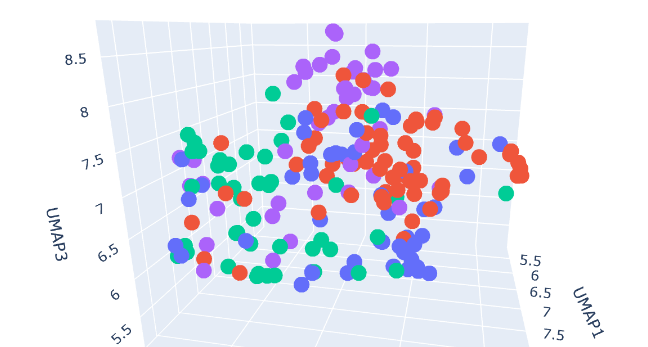

In this this angle I can see somewhat of a grouping happening here where the green points corresponding to joy are placed in the right side while the red ones for the emotion fear are grouped in the right hand side of the plane. This way we can play around the plot to see the points clearly.

---
### <a id='toc1_5_9_'></a>[**2.5 Retrieval-Augmented Generation (RAG)**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

RAG (Retrieval-Augmented Generation) is a technique where a language model combines document retrieval with text generation. In RAG, a retrieval system first finds relevant documents or text chunks, and then the language model uses this retrieved information to generate a more informed and accurate response. This method enhances the model's ability to answer questions by grounding its responses in real, external data.

In the following code, we will load a webpage as a document, which allows us to retrieve text from a URL. After loading the content, we will split the document into smaller, manageable chunks, making it easier for our model to process. Then, we'll generate embeddings for these chunks with a specified LLM model (Gemini Embedding Model). These embeddings will be stored in a vector database, which enables us to perform similarity searches. By setting up this retrieval system, we can use a RAG chain to answer questions. The retriever finds relevant text chunks from the document based on a query, and the LLM generates a response by incorporating this retrieved information, making the answers more grounded and accurate.

In this example we use the library langchain, for documentation on more functions of the library you can check the following link: [LangChain Tutorials](https://python.langchain.com/docs/tutorials/)

In [48]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Function to load, split, and retrieve documents
def load_and_retrieve_docs(url):
    loader = WebBaseLoader(
        web_paths=(url,),
        bs_kwargs=dict() 
    ) 
    docs = loader.load() #We will load the URL that will serve as our data source
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150) #We will divide the URL in chunks of text for easier comparison in the vector space
    splits = text_splitter.split_documents(docs)
    #print(splits) #You can print this to see how the chunks in the url where split
    embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
    vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings) #Our vector space for comparison
    return vectorstore.as_retriever()


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) #Format the retrieved docs in an orderly manner for prompting

# Define the Gemini LLM function
def gemini_llm(question, context):
    system_prompt = "You are a RAG Agent that needs to provide a well structured answer based on the provided question and context."
    formatted_prompt = f"Question: {question}\n\nContext: {context}"
    response, logs = prompt_gemini(input_prompt = formatted_prompt, system_instruction = system_prompt, with_tokens_info = True)
    print(f"logs: \n{logs}")
    # print(f"Retrieved context: \n{context}\n\n") # You can print this to observe the retrieved context
    return response


# Define the RAG chain
def rag_chain(question, retriever):
    retrieved_docs = retriever.invoke(question)
    formatted_context = format_docs(retrieved_docs)
    return gemini_llm(question, formatted_context)


In [49]:
from IPython.display import display, Markdown

url="https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/"
# Create the retriever
retriever = load_and_retrieve_docs(url)

# Use the RAG chain
result = rag_chain(question="What are the Key Challenges in Realizing AGI’s Full Potential", retriever=retriever)
display(Markdown(result))

logs: 
{'model': 'gemini-2.5-flash-lite', 'input_tokens': 731, 'output_tokens': 183}


The key challenges in realizing AGI's full potential include:

*   **Learning from Diverse Data:** Unlike narrow AI, AGI needs to learn from unstructured and diverse data sources, which is a significant hurdle.
*   **Computational Power:** The immense computational resources required to process and learn from vast amounts of data present a considerable challenge.
*   **Ethical Concerns:** Ensuring AGI systems align with human values, addressing issues of autonomy, privacy, and control are crucial.
*   **Job Displacement:** The potential for AGI-driven automation to cause job losses necessitates strategies for workforce transition and retraining.
*   **Security Risks:** Advanced AI systems could be vulnerable to hacking or misuse, posing large-scale security threats.
*   **Unpredictable Behavior:** The complexity of AGI can lead to actions that are difficult to predict or control, potentially resulting in unintended consequences.


##### <a id='toc1_5_9_1_1_'></a>[**Actual answer in the URL:**](#toc0_)

![pic11.png](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/pics/pic11.png?raw=True)

##### <a id='toc1_5_9_1_2_'></a>[**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc0_)

![pic12.png](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/pics/pic12.png?raw=True)

source: https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/


---
##### <a id='toc1_5_9_1_3_'></a>[**>>> Bonus Exercise 5 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Your task is to test the RAG system with your own chosen URL and analyze its performance.

1. Find a URL of a webpage with interesting text content to test the RAG pipeline.
2. Make a question about the content in the webpage you chose.
3. Discuss how good the question was answered by the model, if the model missed important information related to your question.
4. Display a screenshot of the real answer in the webpage.

In [50]:
# Answer here


---
### <a id='toc1_5_10_'></a>[**2.6 Few-Shot Prompting Classification:**](#toc0_)

Few-shot prompting is a technique where a Large Language Model (LLM) is given a small number of labeled examples within a prompt to guide its classification. This allows the model to perform a new task with minimal data, avoiding the need for extensive fine-tuning.

In this lab, we will use the Gemini API to perform zero-shot, 1-shot, and 5-shot emotion classification:

*   **Zero-shot:** The model classifies text without any prior examples.
*   **1-shot:** The model is given one example for each emotion before classifying.
*   **5-shot:** The model is given five examples per emotion for better context.

To make our implementation robust and efficient, we are incorporating two key features:

1.  **Structured Output:** We provide the Gemini model with a specific output schema (`Emotions` class). This instructs the model to return *only* a valid emotion label (e.g., `joy`), which makes the output predictable and reliable, minimizing errors.
2.  **API Rate Handling:** The code includes a function to manage the requests-per-minute limit of the Gemini API.

We will test the model's performance on a small sample of 20 texts per emotion to ensure the process runs quickly. If the model provides an invalid response, the code will automatically retry the request until a valid classification is received.

**Prompt Structure:**
`System Instruction -> Task Description -> Examples (if not zero-shot) -> Text to Classify`


<span style="color:green">For the exercises in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

In [51]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import enum
import os
from tqdm import tqdm
import json
import time
# Define the emotion labels
emotions = ['anger', 'fear', 'joy', 'sadness']
# Define the model to use for few-shot prompting

# Schema for the output, the type enum can be used to make a pool of options if what we want is to classify our text selecting only one of them
class Emotions(enum.StrEnum):
    ANGER = 'anger'
    FEAR = 'fear'
    JOY = 'joy'
    SADNESS = 'sadness'


# Function to handle the rate limits of gemini models
def handle_rate_limit(request_count, first_request_time, max_calls_per_min):
    current_time = time.time()

    # Initialize timer on the first request of a new window
    if request_count == 0:
        first_request_time = current_time

    request_count += 1

    # If the rate limit is reached
    if request_count > max_calls_per_min:
        elapsed_time = current_time - first_request_time
        if elapsed_time < 60:
            wait_time = 60 - elapsed_time
            print(f"Rate limit of {max_calls_per_min} requests per minute reached. Waiting for {wait_time:.2f} seconds.")
            time.sleep(wait_time)

        # Reset for the new window
        request_count = 1
        first_request_time = time.time()
    
    return request_count, first_request_time, max_calls_per_min

# Function to sample examples per emotion category
def sample_few_shots(df, emotions, num_samples=5):
    few_shot_examples = {}
    for emotion in emotions:
        few_shot_examples[emotion] = df[df['emotion'] == emotion].sample(n=num_samples, random_state=42)
    return few_shot_examples

# Function to build the prompt based on the number of examples (few-shot, 1-shot, zero-shot)
def build_prompt(examples, emotions, num_shots=5):
    classification_instructions = """
You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    """
    
    prompt = classification_instructions + "\n\n"
    
    if num_shots > 0:
        prompt += f"Examples: \n"
        for emotion in emotions:
            for _, row in examples[emotion].iterrows():
                prompt += f"Text: {row['text']}\nClass: {emotion}\n\n" #Show the examples in the same format it will be shown for the classification text
                if num_shots == 1:  # If 1-shot, break after the first example for each emotion
                    break
    return prompt

# Function to classify using the LLM with retry for incorrect responses
def classify_with_llm(test_text, prompt_base, system_prompt, classes, schema):
    response = None
    while not response or response not in classes:
        full_prompt = f"{prompt_base}\nClassification:\nText: {test_text}\nClass: " #The classification text will leave the emotion label to be filled in by the LLM
        try:
            result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt)
            # print(f"result: {result} \n")
            # print(f"type: {type(result)}")
            if not result:
                # In case of giving empty responses with temperature 0.0, we set a higher temperature to seek for different responses
                result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt, temperature=1.0)

            try:
                # If the result is in the correct format it can be parsed using json
                response = json.load(result)
            except:
                # In case it's not in a json friendly format
                # Deleting characters " and ' in case they appear in our response with the class of the text 
                response = result.replace('"', '')    
                response = response.replace("'", "")  

                
        # except exceptions.ResourceExhausted as e:
        except Exception as e:
            print(f"Waiting to retry... Error: {e}")
            time.sleep(15)
            print(f"test_text: {test_text}")
            return classify_with_llm(test_text, prompt_base, system_prompt, classes, schema) # Retry the request


        if response not in classes:  # Retry if not a valid response
            print(f"Invalid response: {response}. Asking for reclassification.")
    return response

# Main function to run the experiment with the option for zero-shot, 1-shot, or 5-shot prompting
def run_experiment(df_train, df_test, num_test_samples=5, num_shots=5):
    # Sample examples for few-shot prompting based on num_shots
    if num_shots > 0:
        few_shot_examples = sample_few_shots(df_train, emotions, num_samples=num_shots) 
        prompt_base = build_prompt(few_shot_examples, emotions, num_shots=num_shots)
    else:
        prompt_base = build_prompt(None, emotions, num_shots=0)  # Zero-shot has no examples

    # System prompt for our classification model:
    system_prompt = "You are an emotion classification model for text data. Do not give empty responses, classify according to the list of possible classes."

    # Prepare to classify the test set
    results_data = []

    print(prompt_base)
    # Sample 20 examples per emotion for the test set to classify
    test_samples = sample_few_shots(df_test, emotions, num_samples=num_test_samples)

    # Variables to handle rate limit of gemini
    request_count = 0
    max_calls_per_min = 15 # Gemini 2.5 Flash Lite has this maximum set in the documentation
    first_request_time = None

    # Classify 20 test examples (5 from each category) and save predictions
    for emotion in emotions:
        for _, test_row in tqdm(test_samples[emotion].iterrows(), desc=f"Processing samples for emotion: {emotion}...", total=num_test_samples):
            test_text = test_row['text']
            request_count, first_request_time, max_calls_per_min = handle_rate_limit(request_count, first_request_time, max_calls_per_min)  # Check and handle rate limit before each API call
            predicted_emotion = classify_with_llm(test_text = test_text, prompt_base = prompt_base, system_prompt = system_prompt, classes = emotions, schema = Emotions)
            # Append the results data:
            results_data.append({
                    'text': test_text,
                    'true_emotion': emotion,
                    'predicted_emotion': predicted_emotion
                })

    # Create dataframe to save the results data
    results_df = pd.DataFrame(results_data)
    
    # Extract just the true and predicted labels for metrics calculations
    true_labels = results_df['true_emotion']
    predictions = results_df['predicted_emotion']

    output_dir = "./results/llm_classification_results"
    os.makedirs(output_dir, exist_ok=True)
    # Save the results
    filename = f"{output_dir}/results_samples_{num_test_samples}_shots_{num_shots}.csv"
    
    # Save the DataFrame to CSV
    results_df.to_csv(filename, index=False)
    print(f"\nResults saved to {filename}")

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    print(f"Accuracy: {accuracy * 100:.2f}%")
    
    # Classification report
    print(classification_report(y_true=true_labels, y_pred=predictions))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true=true_labels, y_pred=predictions) 
    my_tags = ['anger', 'fear', 'joy', 'sadness']
    plot_confusion_matrix(cm, classes=my_tags, title=f'Confusion matrix for classification with \n{num_shots}-shot prompting')

**Important: The next part should take around 16 minutes to finish running due to API Rate Limits**

**Note:** You might see an `429 RESOURCE_EXHAUSTED` error when running the following code all at once, this is because the `current API Rate Limit handling cannot reliably find out how many requests we have left per minute` from cell to cell, there is no Gemini feature created for it to get the information from their servers. So, `if you don't want to see the error you can just wait 1 minute` after one cell finished processing. But `even if there is an error showing it is fine`, internally in the code `there is a retry that happens every 15 seconds` until we finish processing our sampled data. `The lab is designed to never reach the total rate limit per day quota.`


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    




Processing samples for emotion: anger...:  75%|███████▌  | 15/20 [00:07<00:02,  1.76it/s]

Rate limit of 15 requests per minute reached. Waiting for 52.75 seconds.


Processing samples for emotion: fear...:  50%|█████     | 10/20 [00:04<00:04,  2.33it/s]

Rate limit of 15 requests per minute reached. Waiting for 53.53 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 53.30 seconds.


Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [00:59<00:02,  1.84it/s]

Rate limit of 15 requests per minute reached. Waiting for 53.52 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:55<00:00,  5.76s/it]



Results saved to ./results/llm_classification_results/results_samples_20_shots_0.csv
Accuracy: 51.25%
              precision    recall  f1-score   support

       anger       0.46      0.65      0.54        20
        fear       0.78      0.35      0.48        20
         joy       0.53      0.80      0.64        20
     sadness       0.38      0.25      0.30        20

    accuracy                           0.51        80
   macro avg       0.54      0.51      0.49        80
weighted avg       0.54      0.51      0.49        80



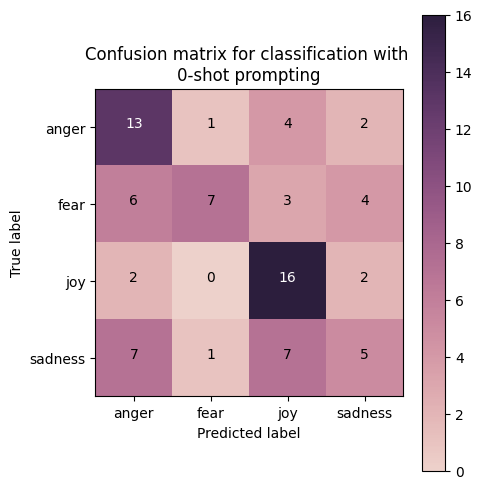

In [53]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with zero-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=0)


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: Why does @dapperlaughs have to come to Glasgow on a night I am working. I am fucking gutted, been waiting for an appearance for ages #raging
Class: anger

Text: Absolutely shocking. The decline of Rooney is a little embarrassing really!
Class: fear

Text: Today I reached 1000 subscribers on YT!! #happy, #goodday, #thankful
Class: joy

Text: Wanna pop some pills, sedate myself, and wake up tomorrow.
Class: sadness




Processing samples for emotion: anger...:  50%|█████     | 10/20 [00:04<00:04,  2.46it/s]

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 45.187006578s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure'

Processing samples for emotion: fear...:  30%|███       | 6/20 [00:02<00:06,  2.32it/s]

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 37.627337871s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions':

...

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 36.468443513s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions':

Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [01:00<01:10, 14.09s/it]

Rate limit of 15 requests per minute reached. Waiting for 8.16 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:10<00:00,  3.53s/it]



Results saved to ./results/llm_classification_results/results_samples_20_shots_1.csv
Accuracy: 60.00%
              precision    recall  f1-score   support

       anger       0.52      0.55      0.54        20
        fear       0.79      0.55      0.65        20
         joy       0.70      0.80      0.74        20
     sadness       0.45      0.50      0.48        20

    accuracy                           0.60        80
   macro avg       0.61      0.60      0.60        80
weighted avg       0.61      0.60      0.60        80



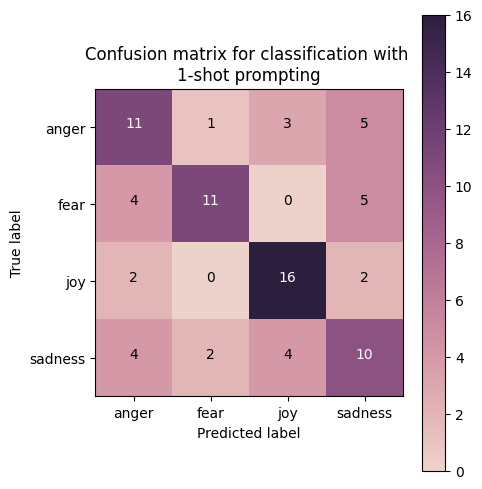

In [54]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 1-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=1)


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: Why does @dapperlaughs have to come to Glasgow on a night I am working. I am fucking gutted, been waiting for an appearance for ages #raging
Class: anger

Text: angry already
Class: anger

Text: Candice's pout is gonna take someone eye out mate! #GBBO
Class: anger

Text: One of my favorite classic cars is the Plymouth fiery.
Class: anger

Text: Tonight's #DragRace #AllStars2 episode GAVE ME LIFE! Yaassss queens! #teamalaska #teamkatya #revenge #bwahaha
Class: anger

Text: Absolutely shocking. The decline of Rooney is a little embarrassing really!
Class: fear

Text: Georgia Tech's Secondary is as soft as a marshmallow.  #horrible
Class: fear

Text: Anyone else find @Microsoft 'anniversary windows 10 update 1607' a Complete 
Class: fear

Text: The focal points of war lie in #terrorism and the

Processing samples for emotion: anger...:  50%|█████     | 10/20 [00:04<00:04,  2.10it/s]

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 35.329353191s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions':

Processing samples for emotion: anger...:  75%|███████▌  | 15/20 [00:52<00:18,  3.76s/it]

Rate limit of 15 requests per minute reached. Waiting for 7.64 seconds.


...

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 33.968851633s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions':

Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [00:59<01:10, 14.09s/it]

Rate limit of 15 requests per minute reached. Waiting for 8.23 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:10<00:00,  3.54s/it]



Results saved to ./results/llm_classification_results/results_samples_20_shots_5.csv
Accuracy: 63.75%
              precision    recall  f1-score   support

       anger       0.60      0.60      0.60        20
        fear       0.92      0.60      0.73        20
         joy       0.71      0.75      0.73        20
     sadness       0.46      0.60      0.52        20

    accuracy                           0.64        80
   macro avg       0.67      0.64      0.65        80
weighted avg       0.67      0.64      0.65        80



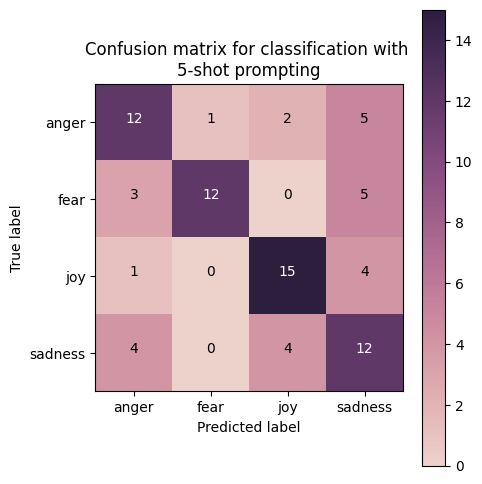

In [55]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 5-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=5)

---
##### <a id='toc1_5_10_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Compare and discuss the overall results of the zero-shot, 1-shot and 5-shot classification.

#### Answer here

Based from the results. Its is observed that the higher the shot or examples given, the higher the overall accuracy from 53.75% when using zero-shot to 60% percent when using 5-shot. However, even with the 5-shot classification, it still has noticeable mistakes like the most of the predicted label for the emotion "anger" are actually labelled as "fear". Hence despite the increased number of examples, the model still has noticeable mistakes.


---
##### <a id='toc1_5_10_1_2_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

**Case Study:** Check the results' files inside the `results/llm_classification_results` directory and find cases where the **text classification improves with more examples** (pred emotion is right with examples), **cases where it does not improve** (pred emotion always wrong) and **cases where the classification got worse with more examples** (pred emotion goes from right to wrong with examples). For this you need to load the results with pandas and handle the data using its dataframe functions. Discuss about the findings.

In [56]:
import pandas as pd
from pathlib import Path
import re

# ============================================================
# Load all result CSV files
# ============================================================
path = Path("results/llm_classification_results")
files = list(path.glob("*.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f.name

    # Extract number of shots from filename
    # Example filename: results_samples_20_shots_5.csv → k = 5
    match = re.search(r"shots_(\d+)", f.name)
    df["k"] = int(match.group(1)) if match else 0

    dfs.append(df)

# Combine
results = pd.concat(dfs, ignore_index=True)

# ============================================================
# Standardize column names
# ============================================================
results = results.rename(columns={
    "true_emotion": "true",
    "predicted_emotion": "pred",
    "text": "text"
})

# Create a unique ID for each text
results["text_id"] = results["text"].factorize()[0]

# Ensure data types
results["k"] = results["k"].astype(int)

# ============================================================
# Classification logic: improved, worse, no improvement
# ============================================================
def classify_behavior(group):
    g = group.sort_values("k")
    first = g.iloc[0]
    last = g.iloc[-1]

    initial_correct = first["pred"] == first["true"]
    final_correct = last["pred"] == last["true"]

    if not initial_correct and final_correct:
        return "improved"
    elif not initial_correct and not final_correct:
        return "no_improvement"
    elif initial_correct and not final_correct:
        return "worse"
    else:
        return "consistently_correct"

case_results = results.groupby("text_id").apply(classify_behavior).reset_index()
case_results.columns = ["text_id", "case"]

# Merge back
results = results.merge(case_results, on="text_id", how="left")

# ============================================================
# PRINT FINDINGS
# ============================================================

print("\n=== SUMMARY OF CASE COUNTS ===")
print(case_results["case"].value_counts(), "\n")

print("=== EXAMPLES OF IMPROVED TEXTS ===")
print(case_results[case_results["case"] == "improved"].head(), "\n")

print("=== EXAMPLES OF NO IMPROVEMENT TEXTS ===")
print(case_results[case_results["case"] == "no_improvement"].head(), "\n")

print("=== EXAMPLES OF WORSE TEXTS ===")
print(case_results[case_results["case"] == "worse"].head(), "\n")

print("=== EXAMPLES OF CONSISTENTLY CORRECT TEXTS ===")
print(case_results[case_results["case"] == "consistently_correct"].head(), "\n")

# Optional detailed breakdown for one improved case
imp_ids = case_results[case_results["case"] == "improved"]["text_id"].tolist()
if imp_ids:
    print("\n=== DETAILED LOOK AT FIRST IMPROVED CASE ===")
    print(results[results["text_id"] == imp_ids[0]].sort_values("k"))



=== SUMMARY OF CASE COUNTS ===
case
consistently_correct    38
no_improvement          26
improved                13
worse                    3
Name: count, dtype: int64 

=== EXAMPLES OF IMPROVED TEXTS ===
    text_id      case
7         7  improved
24       24  improved
29       29  improved
30       30  improved
37       37  improved 

=== EXAMPLES OF NO IMPROVEMENT TEXTS ===
    text_id            case
5         5  no_improvement
8         8  no_improvement
11       11  no_improvement
13       13  no_improvement
14       14  no_improvement 

=== EXAMPLES OF WORSE TEXTS ===
    text_id   case
12       12  worse
19       19  worse
40       40  worse 

=== EXAMPLES OF CONSISTENTLY CORRECT TEXTS ===
   text_id                  case
0        0  consistently_correct
1        1  consistently_correct
2        2  consistently_correct
3        3  consistently_correct
4        4  consistently_correct 


=== DETAILED LOOK AT FIRST IMPROVED CASE ===
                                       text 

/tmp/ipykernel_38/2290521581.py:61: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [57]:
import pandas as pd

# Load all three files
results_shot_0 = pd.read_csv("results/llm_classification_results/results_samples_20_shots_0.csv")
results_shot_1 = pd.read_csv("results/llm_classification_results/results_samples_20_shots_1.csv")
results_shot_5 = pd.read_csv("results/llm_classification_results/results_samples_20_shots_5.csv")

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

combined = pd.DataFrame({
    "text": results_shot_0["text"],
    
    "true": results_shot_0["true_emotion"],

    "pred_0": results_shot_0["predicted_emotion"],
    "pred_1": results_shot_1["predicted_emotion"],
    "pred_5": results_shot_5["predicted_emotion"],
})


In [58]:
import pandas as pd
from pathlib import Path
import re

# ---------------------------
# Load all result files
# ---------------------------
path = Path("results/llm_classification_results")
files = list(path.glob("*.csv"))

dfs = []

for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f.name

    # Extract number of shots from filename
    match = re.search(r"shots_(\d+)", f.name)
    df["k"] = int(match.group(1)) if match else 0

    dfs.append(df)

# Combine into one dataframe
results = pd.concat(dfs, ignore_index=True)

# ---------------------------
# Assign unique text IDs
# ---------------------------
results["text_id"] = results["text"].factorize()[0]

# ---------------------------
# Define function to classify behavior
# ---------------------------
def classify_behavior(group):
    group = group.sort_values("k")
    initial = group.iloc[0]["predicted_emotion"] == group.iloc[0]["true_emotion"]
    final = group.iloc[-1]["predicted_emotion"] == group.iloc[-1]["true_emotion"]

    if not initial and final:
        return "improved"
    elif not initial and not final:
        return "no_improvement"
    elif initial and not final:
        return "worse"
    else:
        return "consistently_correct"

# Apply to each text
case_results = results.groupby("text_id").apply(classify_behavior).reset_index()
case_results.columns = ["text_id", "case"]

# Merge back for reference
results = results.merge(case_results, on="text_id", how="left")

# ---------------------------
# Print counts of each category
# ---------------------------
print("\n=== Counts of text behaviors ===\n")
print(case_results["case"].value_counts())

# ---------------------------
# Print example texts for each category
# ---------------------------
categories = ["improved", "no_improvement", "worse", "consistently_correct"]

for cat in categories:
    print(f"\n=== Examples of {cat} texts ===\n")
    example_ids = case_results[case_results["case"] == cat]["text_id"].tolist()[:3]  # first 3 examples
    for tid in example_ids:
        subset = results[results["text_id"] == tid].sort_values("k")
        print(subset[["k", "predicted_emotion", "true_emotion", "text"]].to_string(index=False))
        print("-" * 80)



=== Counts of text behaviors ===

case
consistently_correct    38
no_improvement          26
improved                13
worse                    3
Name: count, dtype: int64

=== Examples of improved texts ===

 k predicted_emotion true_emotion                                   text
 0               joy        anger @TrussElise Obama must be fuming.. lol
 1               joy        anger @TrussElise Obama must be fuming.. lol
 5             anger        anger @TrussElise Obama must be fuming.. lol
--------------------------------------------------------------------------------
 k predicted_emotion true_emotion                                                                                                                                    text
 0           sadness         fear “We can easily #forgive a #child who is #afraid of the #dark; the real #tragedy of #life is when #men are #afraid of the #light.”–Plato
 1              fear         fear “We can easily #forgive a #child who is #a

/tmp/ipykernel_38/1482066023.py:49: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [59]:
improved = combined[
    (combined["pred_0"] != combined["true"]) &
    (combined["pred_5"] == combined["true"])
]

for i, row in improved.iterrows():
    print("TEXT:", row["text"])
    print("TRUE:", row["true"])
    print("PRED 0:", row["pred_0"])
    print("PRED 1:", row["pred_1"])
    print("PRED 5:", row["pred_5"])
    print("-" * 100)


TEXT: @TrussElise Obama must be fuming.. lol
TRUE: anger
PRED 0: joy
PRED 1: joy
PRED 5: anger
----------------------------------------------------------------------------------------------------
TEXT: “We can easily #forgive a #child who is #afraid of the #dark; the real #tragedy of #life is when #men are #afraid of the #light.”–Plato
TRUE: fear
PRED 0: sadness
PRED 1: fear
PRED 5: fear
----------------------------------------------------------------------------------------------------
TEXT: also i had an awful nightmare involving being sick where worms were involved i was so disgusted when i woke up
TRUE: fear
PRED 0: sadness
PRED 1: fear
PRED 5: fear
----------------------------------------------------------------------------------------------------
TEXT: The moment you bring her to meet your best friend and you're nervous af! 😬😆  #thefriendtest
TRUE: fear
PRED 0: joy
PRED 1: fear
PRED 5: fear
------------------------------------------------------------------------------------------

In [60]:
consistent_wrong = combined[
    (combined["pred_0"] != combined["true"]) &
    (combined["pred_1"] != combined["true"]) &
    (combined["pred_5"] != combined["true"])
]

for i, row in consistent_wrong.iterrows():
    print("TEXT:", row["text"])
    print("TRUE:", row["true"])
    print("PRED 0:", row["pred_0"])
    print("PRED 1:", row["pred_1"])
    print("PRED 5:", row["pred_5"])
    print("-" * 100)

TEXT: Kik to trade, have fun or a conversation  (kik: youraffair) #kik #kikme #messageme #textme #pics #trade #tradepics #dm #snap #bored
TRUE: anger
PRED 0: joy
PRED 1: joy
PRED 5: joy
----------------------------------------------------------------------------------------------------
TEXT: Everybody talking about 'the first day of fall' but summer '16 is never gonna die #revenge @Drake
TRUE: anger
PRED 0: joy
PRED 1: sadness
PRED 5: sadness
----------------------------------------------------------------------------------------------------
TEXT: Having a baby born too soon is #lifechanging 6 years on and it feels like only yesterday #sad #happy  #emotionalrollercoaster
TRUE: anger
PRED 0: sadness
PRED 1: sadness
PRED 5: sadness
----------------------------------------------------------------------------------------------------
TEXT: Ok scrubbed hands 5 times before trying to put them in.\nEyeballs #burning \n#EvenMoreBlind accidentally scared the #cat whilst #screeching
TRUE: anger
P

In [61]:
worse = combined[
    (combined["pred_0"] == combined["true"]) &
    (combined["pred_5"] != combined["true"])
]

for i, row in worse.iterrows():
    print("TEXT:", row["text"])
    print("TRUE:", row["true"])
    print("PRED 0:", row["pred_0"])
    print("PRED 1:", row["pred_1"])
    print("PRED 5:", row["pred_5"])
    print("-" * 100)

TEXT: @RevTrevK @Wolfman93011 @Daraidernation @EROCKhd Take 2k out of it the numbers on madden are low and have dropped and people are unhappy
TRUE: anger
PRED 0: anger
PRED 1: anger
PRED 5: sadness
----------------------------------------------------------------------------------------------------
TEXT: @IllinoisLoyalty that Rutgers game was an abomination. An affront to God and man. We must never speak of it again.
TRUE: anger
PRED 0: anger
PRED 1: anger
PRED 5: sadness
----------------------------------------------------------------------------------------------------
TEXT: Imagine how sad LA fans are gona be when they get eliminated...Man that's gonna be Nirvana, a religious experience rejoicing in their misery
TRUE: joy
PRED 0: joy
PRED 1: joy
PRED 5: sadness
----------------------------------------------------------------------------------------------------


In [62]:
def print_grouped_texts(df, title):
    print(f"\n===== {title} =====\n")
    for text in df["text"]:
        print(text)
        print("-" * 100)

# Print texts grouped by case
print_grouped_texts(improved, "IMPROVED CASES")
print_grouped_texts(consistent_wrong, "CONSISTENTLY WRONG CASES")
print_grouped_texts(worse, "WORSE CASES")


===== IMPROVED CASES =====

@TrussElise Obama must be fuming.. lol
----------------------------------------------------------------------------------------------------
“We can easily #forgive a #child who is #afraid of the #dark; the real #tragedy of #life is when #men are #afraid of the #light.”–Plato
----------------------------------------------------------------------------------------------------
also i had an awful nightmare involving being sick where worms were involved i was so disgusted when i woke up
----------------------------------------------------------------------------------------------------
The moment you bring her to meet your best friend and you're nervous af! 😬😆  #thefriendtest
----------------------------------------------------------------------------------------------------
Not the best horror ever but I like that the uncertainty
----------------------------------------------------------------------------------------------------
@All4 is the android app it des

#### Answer Here

### Improved cases
For the **improved cases** I observed that the reason why the predictions improves with more examples because of the ambiguous contextal clues, more samples would help the model get an idea of the definition for the emotion we expect. In addition, some text gives words that would otherwise interpret the model as a hint but in reality the wrong answe. For example the text:

"HATE that there's ads for #depression &amp; #mentalhealth #meds. That's ONLY something your doctor can determine. Everyone is different. #ssri"

Is initially predicted as anger most likely due to the word "HATE" but in reality its true emotion is labelled as sadness.

### Consistently wrong
For the **consistently wrong** cases, one thing that is quite noticeable is the use of symbols common for social media posts such as @ or #. For example the text:

"@CesarSampao @thisisbolton don't get me started on town centre. Used to go every week.... not been for 18 months"

uses @ which could distract the model in predicting the actual emotion. Moreoverr, the use of informal text could make the model confuse even for more shots like

"FU thugs, 2 Judge #Police w/o all facts yet?"

### Worsen
Lastly, for the **worsen** results with more examples, one thing that I observed are the use of symbols. Although similar to the consitently wrong examples, this could also make the model interpret differently.


---
### <a id='toc1_5_11_'></a>[**2.7 Extra LLM Related Materials:**](#toc0_)
So this will be it for the lab, but here are some extra materials if you would like to explore:

- **How to use OpenAI ChatGPT model's API (Not Free API):** [Basics Video](https://www.youtube.com/watch?v=e9P7FLi5Zy8), [Basics GitHub](https://github.com/gkamradt/langchain-tutorials/blob/main/chatapi/ChatAPI%20%2B%20LangChain%20Basics.ipynb), [RAG's Basics Video](https://www.youtube.com/watch?v=9AXP7tCI9PI&t=300s), [RAG's Basics GitHub](https://github.com/techleadhd/chatgpt-retrieval)

- **Advanced topic - QLoRA (Quantized Low-Rank Adapter):** QLoRA is a method used to make fine-tuning large language models more efficient. It works by adding a small, trainable part (LoRA) to a pre-trained model, while keeping the rest of the model frozen. At the same time, it reduces the size of the model’s data using a process called quantization, which makes the model require less memory. This allows you to fine-tune large models without needing as much computational power, making it easier to adapt models for specific tasks. Materials: [Paper GitHub](https://github.com/artidoro/qlora?tab=readme-ov-file), [Llama 3 Application Video](https://www.youtube.com/watch?v=YJNbgusTSF0&t=512s),[Llama 3 Application GitHub](https://github.com/adidror005/youtube-videos/blob/main/LLAMA_3_Fine_Tuning_for_Sequence_Classification_Actual_Video.ipynb)

- **How to Fine-tune and run local LLMs with the `unsloth` library:** [unsloth tutorials](https://docs.unsloth.ai/models/tutorials-how-to-fine-tune-and-run-llms)

- **Google's Agent Development Kit Documentation:** [ADK](https://google.github.io/adk-docs/)

- **Build AI agents with LangGraph:** [LangGraph Documentation](https://langchain-ai.github.io/langgraph/concepts/why-langgraph/)

---